In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/credit_risk_dataset.csv')

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
df.columns.to_list()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [ ]:
df.shape

(32581, 12)

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


# **2 clear outliers:**

In [ ]:
print(df.isnull().sum()/ len(df)*100)

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


In [ ]:
df['person_emp_length'].fillna(df['person_emp_length'].median(),inplace=True)

/tmp/ipykernel_3175/258519556.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(),inplace=True)


In [ ]:
df['loan_int_rate'].fillna(df['loan_int_rate'].median(),inplace=True)

/tmp/ipykernel_3175/1722227870.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(df['loan_int_rate'].median(),inplace=True)


In [ ]:
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [ ]:
print(df[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']].describe())

         person_age  person_income     loan_amnt  loan_int_rate
count  32581.000000   3.258100e+04  32581.000000   32581.000000
mean      27.734600   6.607485e+04   9589.371106      11.009620
std        6.348078   6.198312e+04   6322.086646       3.081611
min       20.000000   4.000000e+03    500.000000       5.420000
25%       23.000000   3.850000e+04   5000.000000       8.490000
50%       26.000000   5.500000e+04   8000.000000      10.990000
75%       30.000000   7.920000e+04  12200.000000      13.110000
max      144.000000   6.000000e+06  35000.000000      23.220000


In [ ]:
df = df[df['person_age'] < 100]

In [ ]:
income_99 = df['person_income'].quantile(0.99)
df = df[df['person_income'] < income_99]

In [ ]:
print(df.shape)

(32223, 12)


In [ ]:
print(df[['person_age','person_income']].describe())

         person_age  person_income
count  32223.000000   32223.000000
mean      27.663625   62558.633336
std        6.171219   34006.005087
min       20.000000    4000.000000
25%       23.000000   38400.000000
50%       26.000000   55000.000000
75%       30.000000   78000.000000
max       94.000000  224000.000000


In [ ]:
print(df[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']].describe())

         person_age  person_income     loan_amnt  loan_int_rate
count  32223.000000   32223.000000  32223.000000   32223.000000
mean      27.663625   62558.633336   9502.268566      11.000048
std        6.171219   34006.005087   6221.944686       3.078603
min       20.000000    4000.000000    500.000000       5.420000
25%       23.000000   38400.000000   5000.000000       8.490000
50%       26.000000   55000.000000   8000.000000      10.990000
75%       30.000000   78000.000000  12000.000000      13.110000
max       94.000000  224000.000000  35000.000000      23.220000


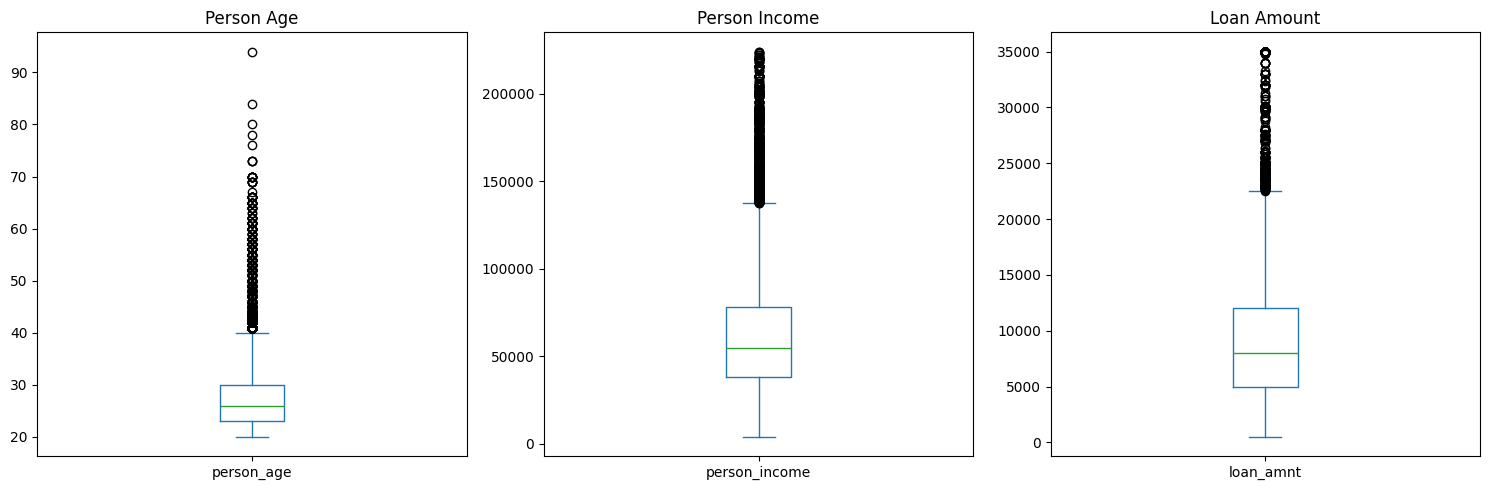

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

df['person_age'].plot(kind='box', ax=axes[0], title='Person Age')
df['person_income'].plot(kind='box', ax=axes[1], title='Person Income')
df['loan_amnt'].plot(kind='box', ax=axes[2], title='Loan Amount')

plt.tight_layout()
plt.show()

# **Categorical Encoding:**

In [ ]:
print(df.dtypes)

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
cat_col = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

for col in cat_col:
  df[col] = le.fit_transform(df[col])

In [ ]:
print(df.head())

   person_age  person_income  person_home_ownership  person_emp_length  \
0          22          59000                      3              123.0   
1          21           9600                      2                5.0   
2          25           9600                      0                1.0   
3          23          65500                      3                4.0   
4          24          54400                      3                8.0   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_status  \
0            4           3      35000          16.02            1   
1            1           1       1000          11.14            0   
2            3           2       5500          12.87            1   
3            3           2      35000          15.23            1   
4            3           2      35000          14.27            1   

   loan_percent_income  cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                          1           


# **EDA**

**Loan status distribution**

In [46]:
print(df.columns.to_list())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


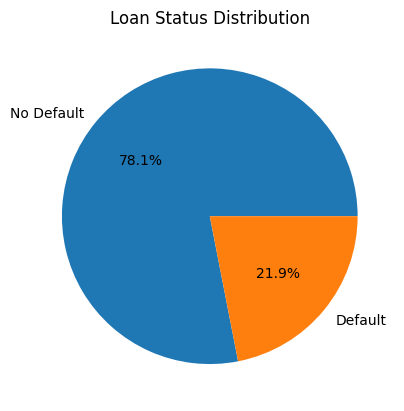

In [59]:
loan_status = df['loan_status'].value_counts()

plt.pie(loan_status, labels=['No Default', 'Default'], autopct='%1.1f%%')
plt.title('Loan Status Distribution')
plt.show()

 **Loan intent wise default rate**

In [62]:
loan_wise_intent = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False).head(10)

In [63]:
print(loan_wise_intent)

loan_intent
0    0.286935
3    0.267355
2    0.263721
4    0.200807
1    0.172732
5    0.149399
Name: loan_status, dtype: float64


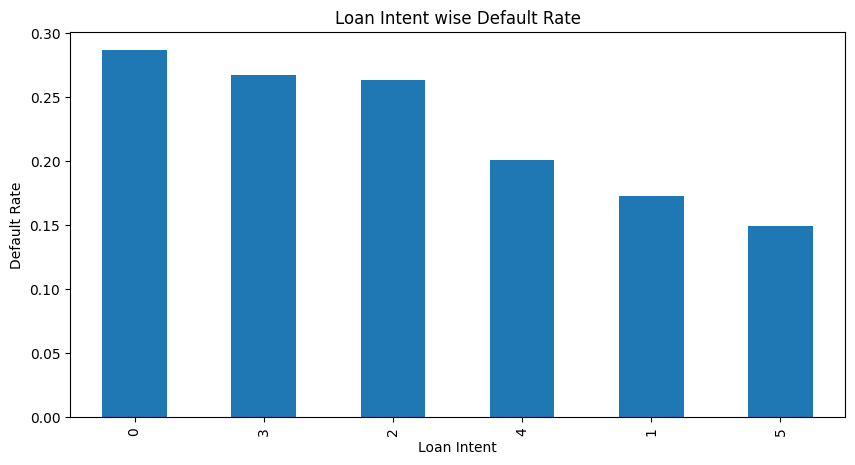

In [65]:

loan_wise_intent.plot(kind='bar', figsize=(10,5), title='Loan Intent wise Default Rate')
plt.xlabel('Loan Intent')
plt.ylabel('Default Rate')
plt.show()

**Income vs Loan Amount **

In [69]:
Income_vs_Loan_Amount = df.groupby('person_income')['loan_amnt'].sum().sort_values(ascending=False).head()

In [70]:
print(Income_vs_Loan_Amount)

person_income
60000    10208250
50000     6835850
75000     6443325
30000     5720800
70000     5596125
Name: loan_amnt, dtype: int64


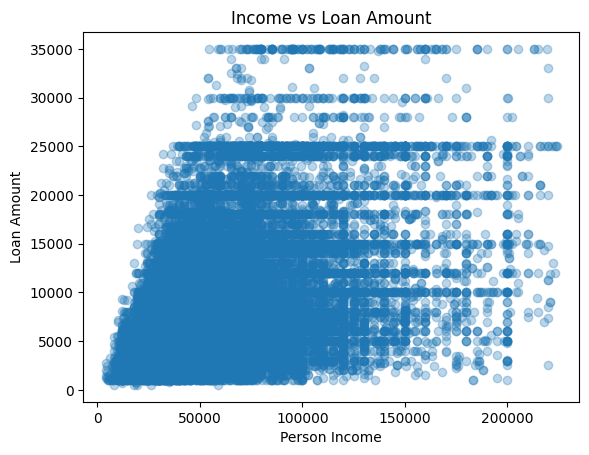

In [71]:
plt.scatter(df['person_income'], df['loan_amnt'], alpha=0.3)
plt.xlabel('Person Income')
plt.ylabel('Loan Amount')
plt.title('Income vs Loan Amount')
plt.show()

**Which loan grade has the highest interest rate?**

In [78]:
import matplotlib.pyplot as plt


In [80]:
loan_grade_interest = df.groupby('loan_grade')['loan_int_rate'].mean().sort_values(ascending=False)
print(loan_grade_interest)

loan_grade
6    19.481111
5    17.741362
4    16.476032
3    14.982998
2    13.218900
1    10.996667
0     7.667565
Name: loan_int_rate, dtype: float64


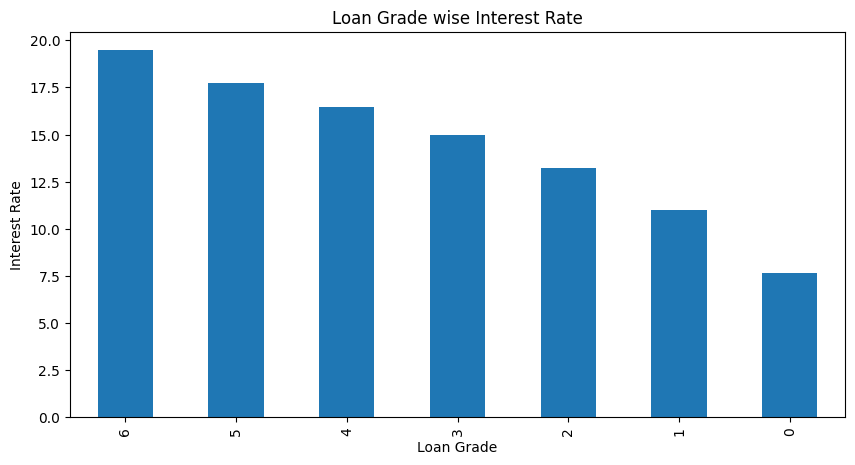

In [81]:
loan_grade_interest.plot(kind='bar', figsize=(10,5), title='Loan Grade wise Interest Rate')
plt.xlabel('Loan Grade')
plt.ylabel('Interest Rate')
plt.show()

In [82]:
ownership = df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)

In [83]:
print(ownership)

person_home_ownership
1    0.317308
3    0.316455
0    0.125919
2    0.075117
Name: loan_status, dtype: float64


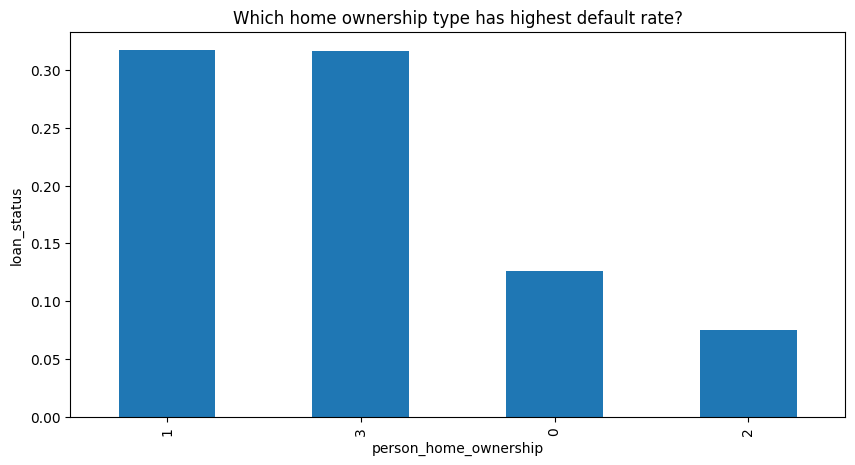

In [84]:
ownership.plot(kind='bar', figsize=(10,5), title='Which home ownership type has highest default rate?')
plt.xlabel('person_home_ownership')
plt.ylabel('loan_status')
plt.show()

# **## ML Model — Loan Default Prediction using Random Forest Classifier**

In [85]:
from sklearn.model_selection import train_test_split

In [88]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [89]:
X_train,X_test,y_train,y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [90]:
from sklearn.ensemble import RandomForestClassifier

In [91]:
model = RandomForestClassifier(n_estimators=100 , random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [92]:
y_pred = model.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [94]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9329712955779674
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5067
           1       0.98      0.70      0.82      1378

    accuracy                           0.93      6445
   macro avg       0.95      0.85      0.89      6445
weighted avg       0.94      0.93      0.93      6445

[[5043   24]
 [ 408  970]]
